### Baseline Conductivity Prediction and Alignment Evaluation for Generated SMILES

To check whether the generators really follow the *high / low conductivity* prompts, we use a separate supervised model as an oracle. First, we train a baseline conductivity classifier on the HTP-MD dataset: each SMILES is converted to a 2048-bit Morgan fingerprint (radius = 2), and we fit a RandomForest and XGBoost model. Both models reach ≈0.99 ROC-AUC on a held-out test set, so the RandomForest is used as a reasonably calibrated proxy for “P(high conductivity)”.

For each generator (minGPT, GPT-4o, LLaMA, and fine-tuned LLaMA), and for each prompt type (high vs low), we then:
1) compute fingerprints for all generated SMILES,
2) obtain the RandomForest’s predicted probability of high conductivity, P(high), for every molecule,
3) compare the distributions of P(high) for high-prompt vs low-prompt samples and compute an “alignment AUC” by treating high-prompt molecules as label 1 and low-prompt molecules as label 0.

If the high-prompt molecules tend to have large P(high) and the low-prompt molecules small P(high), the two distributions separate and the alignment AUC is close to 1. This indicates that the generator is not only producing valid polymers, but is also aligned with the intended property direction according to an external predictor.


In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# RDKit: molecular fingerprints
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

### Data Loading and Molecular Fingerprint Features

In [4]:
csv_path = "../../minGPT/htp_md.csv"

df = pd.read_csv(csv_path, sep="\t") 
print(df.head())
print(df.dtypes)
print(df["conductivity"].value_counts())

                         mol_smiles  conductivity
0      NC(=O)CSCC(CO[Cu])OC(=O)[Au]             1
1  CCC(F)C(=O)NC(CO[Cu])COC(=O)[Au]             0
2       CCSCCN(CCN[Cu])CCOC(=O)[Au]             1
3     C#CCN(CCOCCO[Cu])CCOC(=O)[Au]             1
4     CCC(COC(=O)[Au])C(=O)NCCO[Cu]             0
mol_smiles      object
conductivity     int64
dtype: object
conductivity
1    5704
0    5704
Name: count, dtype: int64


In [5]:
# SMILES → Morgan fingerprint features
# We write a helper function that converts each SMILES into a 2048-dimensional bit vector
# (the same type of fingerprint used in the PolyGen metrics: radius=2, nBits=2048).
def smiles_to_morgan(smiles, radius=2, n_bits=2048):
    """Convert a SMILES string to a Morgan fingerprint (numpy array)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Convert the entire dataset into features
X_list = []
y_list = []

for smi, label in zip(df["mol_smiles"], df["conductivity"]):
    fp = smiles_to_morgan(smi)
    if fp is not None:
        X_list.append(fp)
        y_list.append(label)

X = np.vstack(X_list)
y = np.array(y_list)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (11408, 2048)
Labels shape: (11408,)


### Training Baseline Conductivity Classifiers (Random Forest and XGBoost)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Keep the 0/1 class ratio consistent
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Define a simple RandomForest baseline
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

Train size: 9126
Test size: 2282


RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [7]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy  : {acc:.3f}")
print(f"F1-score  : {f1:.3f}")
print(f"ROC-AUC   : {auc:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy  : 0.990
F1-score  : 0.990
ROC-AUC   : 1.000

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1141
           1       0.98      1.00      0.99      1141

    accuracy                           0.99      2282
   macro avg       0.99      0.99      0.99      2282
weighted avg       0.99      0.99      0.99      2282

Confusion matrix:
[[1119   22]
 [   0 1141]]


In [7]:
# !pip install xgboost

In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# define XGBoost model
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

# train
xgb.fit(X_train, y_train)

# predict
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# evaluate
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"XGBoost Accuracy : {acc_xgb:.3f}")
print(f"XGBoost F1-score : {f1_xgb:.3f}")
print(f"XGBoost ROC-AUC  : {auc_xgb:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


XGBoost Accuracy : 0.968
XGBoost F1-score : 0.969
XGBoost ROC-AUC  : 0.994

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1141
           1       0.94      1.00      0.97      1141

    accuracy                           0.97      2282
   macro avg       0.97      0.97      0.97      2282
weighted avg       0.97      0.97      0.97      2282

Confusion matrix:
[[1068   73]
 [   0 1141]]


### Evaluating Generated SMILES with the Random Forest Predictor

In [12]:
import json
from pathlib import Path

DATA_DIR = Path("../../data")

with open(DATA_DIR / "generated/mingpt/generated_high.json") as f:
    high_results = json.load(f)

with open(DATA_DIR / "generated/mingpt/generated_low.json") as f:
    low_results = json.load(f)

with open(DATA_DIR / "generated/gpt4o/gpt4o_low_clean.json") as f:
    gpt4o_low_clean = json.load(f)

with open(DATA_DIR / "generated/gpt4o/gpt4o_high_clean.json") as f:
    gpt4o_high_clean = json.load(f)

with open(DATA_DIR / "generated/llama/llama_low_clean.json") as f:
    llama_low_clean = json.load(f)

with open(DATA_DIR / "generated/llama/llama_high_clean.json") as f:
    llama_high_clean = json.load(f)

with open(DATA_DIR / "generated/llama_tuned/llama_low_tuned.json") as f:
    llama_low_tuned = json.load(f)
    
with open(DATA_DIR / "generated/llama_tuned/llama_high_tuned.json") as f:
    llama_high_tuned = json.load(f)

In [9]:
import numpy as np

def smiles_list_to_matrix(smiles_list):
    """Convert a set of SMILES into an (n, 2048) Morgan fingerprint matrix, filtering out entries that failed parsing"""
    fps = []
    for smi in smiles_list:
        fp = smiles_to_morgan(smi)   
        if fp is not None:
            fps.append(fp)
    return np.vstack(fps)


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def evaluate_pair(name, high_list, low_list, plot_hist=True):
    # 1) SMILES → features
    X_high = smiles_list_to_matrix(high_list)
    X_low  = smiles_list_to_matrix(low_list)

    print(f"\n===== {name} =====")
    print("High set shape:", X_high.shape)
    print("Low  set shape:", X_low.shape)

    # 2) Use RF to predict P(high)
    high_proba = rf.predict_proba(X_high)[:, 1]
    low_proba  = rf.predict_proba(X_low)[:, 1]

    print(f"Mean P(high) for {name} high-prompt samples : {high_proba.mean():.3f}")
    print(f"Mean P(high) for {name} low-prompt  samples : {low_proba.mean():.3f}")

    # 3) Alignment AUC
    y_scores = np.concatenate([high_proba, low_proba])
    y_labels = np.concatenate([
        np.ones_like(high_proba),   # high-prompt → 1
        np.zeros_like(low_proba),   # low-prompt  → 0
    ])
    auc = roc_auc_score(y_labels, y_scores)
    print(f"Alignment AUC for {name}: {auc:.3f}")

    # 4) histogram
    if plot_hist:
        plt.figure()
        plt.hist(high_proba, bins=20, alpha=0.6, label="High prompt")
        plt.hist(low_proba,  bins=20, alpha=0.6, label="Low prompt")
        plt.xlabel("Predicted P(high conductivity)")
        plt.ylabel("Count")
        plt.title(f"{name}: predicted conductivity distribution")
        plt.legend()
        plt.show()

    # Return results as a dictionary
    return {
        "Model": name,
        "Mean_P_high_highPrompt": float(high_proba.mean()),
        "Mean_P_high_lowPrompt": float(low_proba.mean()),
        "Alignment_AUC": float(auc),
    }


[09:39:51] SMILES Parse Error: extra close parentheses while parsing: CC(C)(C)COCCNC(=O)[Au])N[Cu]
[09:39:51] SMILES Parse Error: Failed parsing SMILES 'CC(C)(C)COCCNC(=O)[Au])N[Cu]' for input: 'CC(C)(C)COCCNC(=O)[Au])N[Cu]'
[09:39:51] SMILES Parse Error: extra close parentheses while parsing: NOCCNCC(=O)[Au])NCCO[Cu]
[09:39:51] SMILES Parse Error: Failed parsing SMILES 'NOCCNCC(=O)[Au])NCCO[Cu]' for input: 'NOCCNCC(=O)[Au])NCCO[Cu]'
[09:39:51] SMILES Parse Error: extra close parentheses while parsing: COCC(CNCC=O)CCN[Cu])OC(=O)[Au]
[09:39:51] SMILES Parse Error: Failed parsing SMILES 'COCC(CNCC=O)CCN[Cu])OC(=O)[Au]' for input: 'COCC(CNCC=O)CCN[Cu])OC(=O)[Au]'
[09:39:51] SMILES Parse Error: extra open parentheses for input: 'C=CC(CO[Cu])NCC(COCC(=O)[Au]'
[09:39:51] SMILES Parse Error: extra close parentheses while parsing: COC(CO[Cu])N(C)CC(C)O[Cu])OC(=O)[Au]
[09:39:51] SMILES Parse Error: Failed parsing SMILES 'COC(CO[Cu])N(C)CC(C)O[Cu])OC(=O)[Au]' for input: 'COC(CO[Cu])N(C)CC(C)O[Cu


===== minGPT =====
High set shape: (96, 2048)
Low  set shape: (80, 2048)
Mean P(high) for minGPT high-prompt samples : 0.665
Mean P(high) for minGPT low-prompt  samples : 0.062
Alignment AUC for minGPT: 0.957


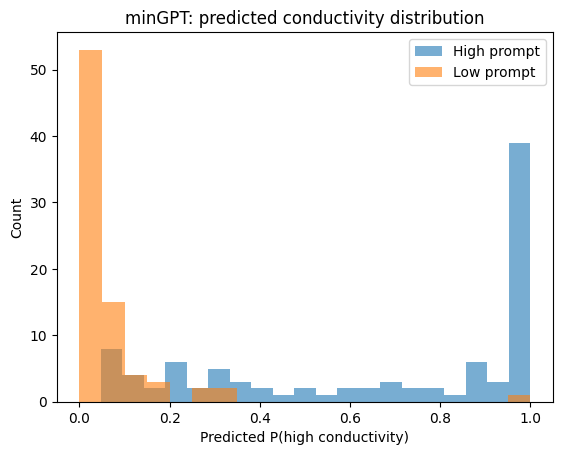

[09:39:52] SMILES Parse Error: syntax error while parsing: O=C(O)CCN[C(CO)[Cu]]CO[Au]
[09:39:52] SMILES Parse Error: Failed parsing SMILES 'O=C(O)CCN[C(CO)[Cu]]CO[Au]' for input: 'O=C(O)CCN[C(CO)[Cu]]CO[Au]'
[09:39:52] Explicit valence for atom # 1 O, 3, is greater than permitted
[09:39:52] SMILES Parse Error: syntax error while parsing: CC(=O)C[C[Cu]]N(COC)[Au]
[09:39:52] SMILES Parse Error: Failed parsing SMILES 'CC(=O)C[C[Cu]]N(COC)[Au]' for input: 'CC(=O)C[C[Cu]]N(COC)[Au]'
[09:39:52] SMILES Parse Error: syntax error while parsing: O=CCOCC[C[Cu]]N(=O)[Au]
[09:39:52] SMILES Parse Error: Failed parsing SMILES 'O=CCOCC[C[Cu]]N(=O)[Au]' for input: 'O=CCOCC[C[Cu]]N(=O)[Au]'
[09:39:52] SMILES Parse Error: syntax error while parsing: NC(=O)NCC(=O)C[Cu]C[CO][Au]
[09:39:52] SMILES Parse Error: Failed parsing SMILES 'NC(=O)NCC(=O)C[Cu]C[CO][Au]' for input: 'NC(=O)NCC(=O)C[Cu]C[CO][Au]'
[09:39:52] Explicit valence for atom # 1 O, 3, is greater than permitted
[09:39:52] SMILES Parse Error: syn


===== GPT-4o =====
High set shape: (67, 2048)
Low  set shape: (73, 2048)
Mean P(high) for GPT-4o high-prompt samples : 0.107
Mean P(high) for GPT-4o low-prompt  samples : 0.014
Alignment AUC for GPT-4o: 0.951


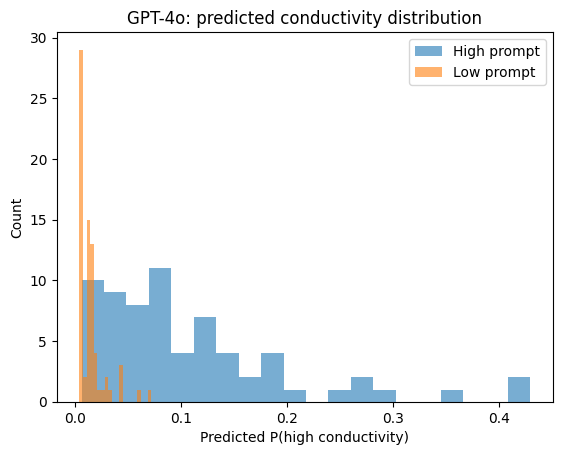

[09:39:52] SMILES Parse Error: syntax error while parsing: SCC(O)C(COOH)[Cu]C(CO)OC(=O)[Au]
[09:39:52] SMILES Parse Error: Failed parsing SMILES 'SCC(O)C(COOH)[Cu]C(CO)OC(=O)[Au]' for input: 'SCC(O)C(COOH)[Cu]C(CO)OC(=O)[Au]'
[09:39:52] SMILES Parse Error: unclosed ring for input: 'C1CC(NC(=O)CSCC(CO[Cu])OC(=O)[Au])'
[09:39:52] SMILES Parse Error: unclosed ring for input: 'C1CCSC(CO[Cu])NCCO(CO)[Au]'
[09:39:52] Explicit valence for atom # 1 O, 3, is greater than permitted
[09:39:52] Explicit valence for atom # 9 O, 3, is greater than permitted
[09:39:52] SMILES Parse Error: unclosed ring for input: 'C1C(SCCC)NC(NCCO(CO[Cu])OC(=O)[Au])'
[09:39:52] SMILES Parse Error: unclosed ring for input: 'OC(CO)NCCO(CO[Cu])COC(=O)[Au]C1CC'
[09:39:52] SMILES Parse Error: unclosed ring for input: 'CCCC(CO)NC(CO[Cu])OC(=O)[Au]C1CC'
[09:39:52] SMILES Parse Error: unclosed ring for input: 'OCC(NCCO(CO[Cu])OC(=O)[Au])COC(=O)C1CC'
[09:39:52] SMILES Parse Error: unclosed ring for input: 'OCC(CO)NCCO(CO[Cu])


===== LLaMA-3.2-3B =====
High set shape: (93, 2048)
Low  set shape: (67, 2048)
Mean P(high) for LLaMA-3.2-3B high-prompt samples : 0.148
Mean P(high) for LLaMA-3.2-3B low-prompt  samples : 0.033
Alignment AUC for LLaMA-3.2-3B: 0.901


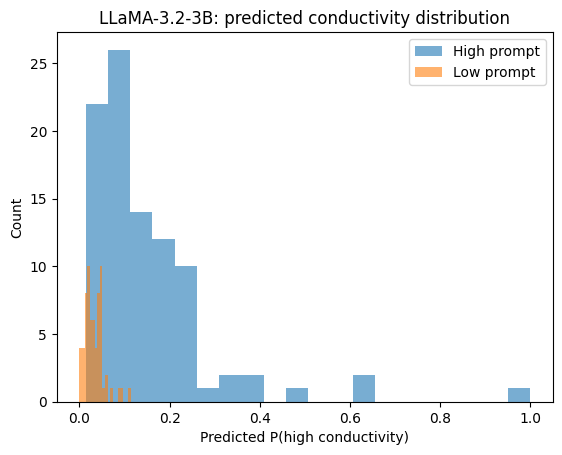

[09:39:53] Explicit valence for atom # 1 C, 5, is greater than permitted
[09:39:53] Explicit valence for atom # 1 C, 6, is greater than permitted



===== LLaMA-3.2-3B (LoRA-tuned) =====
High set shape: (99, 2048)
Low  set shape: (99, 2048)
Mean P(high) for LLaMA-3.2-3B (LoRA-tuned) high-prompt samples : 0.438
Mean P(high) for LLaMA-3.2-3B (LoRA-tuned) low-prompt  samples : 0.423
Alignment AUC for LLaMA-3.2-3B (LoRA-tuned): 0.511


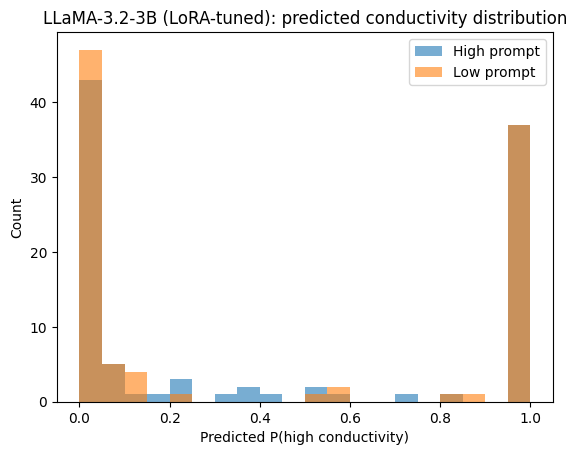

In [13]:
results = []
results.append(evaluate_pair("minGPT", high_results, low_results))
results.append(evaluate_pair("GPT-4o", gpt4o_high_clean, gpt4o_low_clean))
results.append(evaluate_pair("LLaMA-3.2-3B", llama_high_clean, llama_low_clean))
results.append(evaluate_pair("LLaMA-3.2-3B (LoRA-tuned)", llama_high_tuned, llama_low_tuned))


Intuitive interpretation: The closer high_proba.mean() is to 1, the more the molecules generated by the high prompt
are considered “high conductivity” by the Random Forest.

The closer low_proba.mean() is to 0, the more the molecules generated by the low prompt
are considered “low conductivity” by the Random Forest.
The larger the gap between the two, the better the conditional control.
